In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      
from sklearn.model_selection import train_test_split


In [3]:
X_train_rough = np.load('data/X_train_rough.npy')
X_train_np = np.load('data/X_train_np.npy')
y_train_np = np.load('data/y_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


In [4]:
plt.ioff()
wavelengths = np.linspace(1550, 1565, 1500)

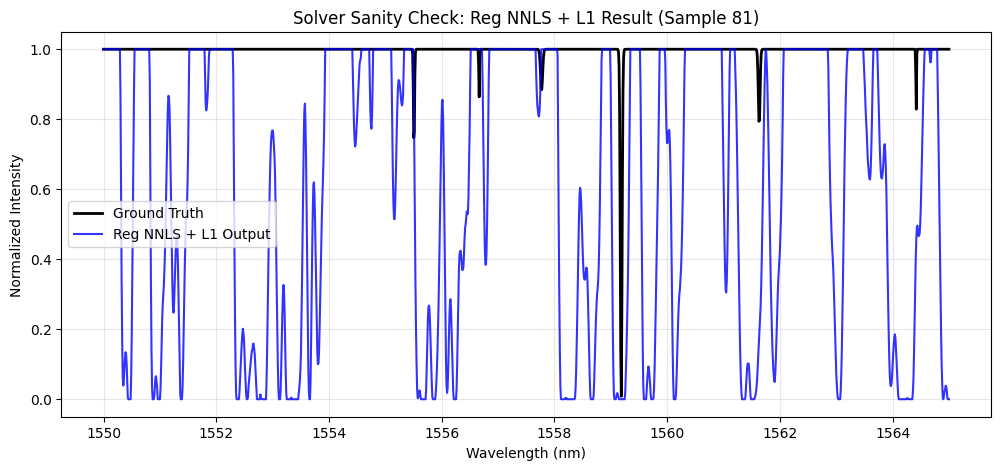

In [55]:
# plot one graph to see
sample_idx = 81
plt.figure(figsize=(12, 5))
plt.plot(wavelengths, y_train_np[sample_idx], label="Ground Truth", color="black", linewidth=2)
plt.plot(wavelengths, X_train_rough[sample_idx], label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=True)



In [6]:
# add classification network

class ClasificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(25, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 2)

        # activation functions
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x



In [7]:
classificationModel = ClasificationNetwork()
classificationModel.load_state_dict(torch.load('data/classification_model.pth'))
classificationModel.eval()


ClasificationNetwork(
  (layer1): Linear(in_features=25, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=2, bias=True)
  (ReLU): ReLU()
)

In [8]:
# Calculate and save normalization statistics
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

# Save these for later use
np.save('data/normalization_mean.npy', mean)
np.save('data/normalization_std.npy', std)

print(f"Mean shape: {mean.shape}")
print(f"Std shape: {std.shape}")

Mean shape: (25,)
Std shape: (25,)


In [10]:
# Load normalization statistics
mean = np.load('data/normalization_mean.npy')
std = np.load('data/normalization_std.npy')

# Get multiple samples
samples = X_train_np[:10]  # First 10 samples

# Normalize the samples using the SAME mean and std as training
samples_normalized = (samples - mean) / std

# Convert to tensor
samples_tensor = torch.from_numpy(samples_normalized).float()  # Shape: (10, 25)

# Make predictions
with torch.no_grad():
    outputs = classificationModel(samples_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)


print(f"Predicted classes: {predicted_classes.numpy()}")
# [prob of 0, prob of 1]
print(f"Probabilities:\n{probabilities}")
print(labels_list[:10])


Predicted classes: [0 0 1 1 1 1 0 0 1 0]
Probabilities:
tensor([[9.9564e-01, 4.3559e-03],
        [9.9292e-01, 7.0766e-03],
        [8.3823e-04, 9.9916e-01],
        [1.1855e-06, 1.0000e+00],
        [6.1269e-05, 9.9994e-01],
        [1.4914e-06, 1.0000e+00],
        [9.9465e-01, 5.3537e-03],
        [9.9437e-01, 5.6274e-03],
        [2.4670e-06, 1.0000e+00],
        [9.9311e-01, 6.8909e-03]])
['generate_sparse_spectrum' 'generate_sparse_spectrum'
 'generate_broad_emission' 'generate_broad_absorption'
 'generate_broad_absorption' 'generate_broad_emission'
 'generate_narrow_absorption' 'generate_sparse_spectrum'
 'generate_broad_emission' 'generate_sparse_spectrum']


In [11]:
# Network for broad


# subset data for just broad
broad_types = ["generate_broad_emission", "generate_broad_absorption"]

broad_mask = np.array([label in broad_types for label in labels_list])

# inputs: rough broad spectrums
X_broad_rough = X_train_rough[broad_mask]
# validation broad truth
y_broad_true = y_train_np[broad_mask]

print(f"Total broad samples: {len(X_broad_rough)}")
print(f"Input shape: {X_broad_rough.shape}")
print(f"Target shape: {y_broad_true.shape}")


Total broad samples: 1479
Input shape: (1479, 1500)
Target shape: (1479, 1500)


In [14]:
# split into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X_broad_rough, y_broad_true,
    test_size=0.2,
    random_state=42
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Training: 1183 samples
Test: 296 samples


In [16]:
# Make dataset viable for PyTorch

class BroadSpectrumDataset(Dataset):
    # convert to tensors
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    # so that batches can be created
    def __len__(self):
        return len(self.X)

    # called during training when creating data
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BroadSpectrumDataset(X_train, y_train)
# feed batch_size input target pairs at once and shuffle
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Number of batches: {len(train_loader)}")


Number of batches: 37


In [68]:
# Broad Network

class BroadSolverNetwork(nn.Module):
    def __init__(self):
        super().__init__()
    
        self.layer1 = nn.Linear(1500, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)

        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x





In [70]:
# loss function

def broad_loss(predicted, target, smoothness_lambda = 0.1):

    # how close
    mse = nn.MSELoss()(predicted, target)

    # how smooth, penalize big jumps
    smoothness = torch.mean((predicted[:, 1:] - predicted[:, :-1]) ** 2)

    return mse + smoothness_lambda * smoothness

In [71]:
model = BroadSolverNetwork()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer.zero_grad()
        loss.backward()

        # update the weights
        optimizer.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.007729
Epoch 20/200, Loss: 0.005130
Epoch 30/200, Loss: 0.003869
Epoch 40/200, Loss: 0.003402
Epoch 50/200, Loss: 0.003110
Epoch 60/200, Loss: 0.002690
Epoch 70/200, Loss: 0.002240
Epoch 80/200, Loss: 0.002526
Epoch 90/200, Loss: 0.001903
Epoch 100/200, Loss: 0.002216
Epoch 110/200, Loss: 0.001539
Epoch 120/200, Loss: 0.001682
Epoch 130/200, Loss: 0.001271
Epoch 140/200, Loss: 0.001419
Epoch 150/200, Loss: 0.001521
Epoch 160/200, Loss: 0.001481
Epoch 170/200, Loss: 0.001120
Epoch 180/200, Loss: 0.001365
Epoch 190/200, Loss: 0.000993
Epoch 200/200, Loss: 0.000973


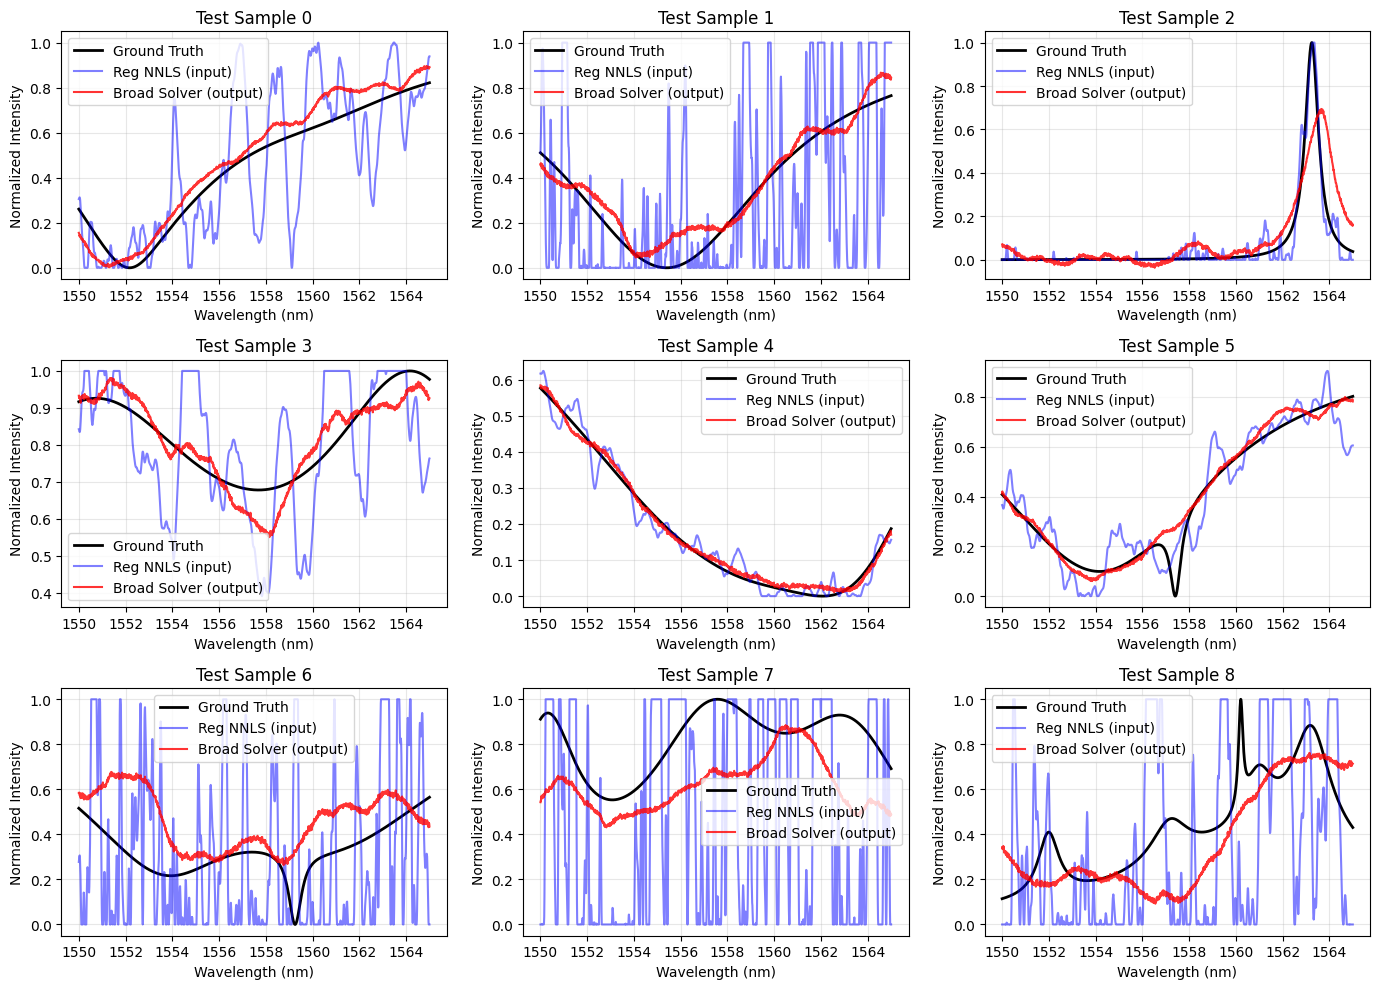

<Figure size 640x480 with 0 Axes>

In [72]:
model.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# Plot a few examples
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i in range(9):
    ax = axes[i]
    ax.plot(wavelengths, y_test[i], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[i], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[i], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {i}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("broadoutput.png")

In [73]:
mse_before = np.mean((X_test - y_test) ** 2)
mse_after = np.mean((predictions - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after (Broad Solver): {mse_after:.6f}")
print(f"Improvement: {((mse_before - mse_after) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after (Broad Solver): 0.011056
Improvement: 85.1%


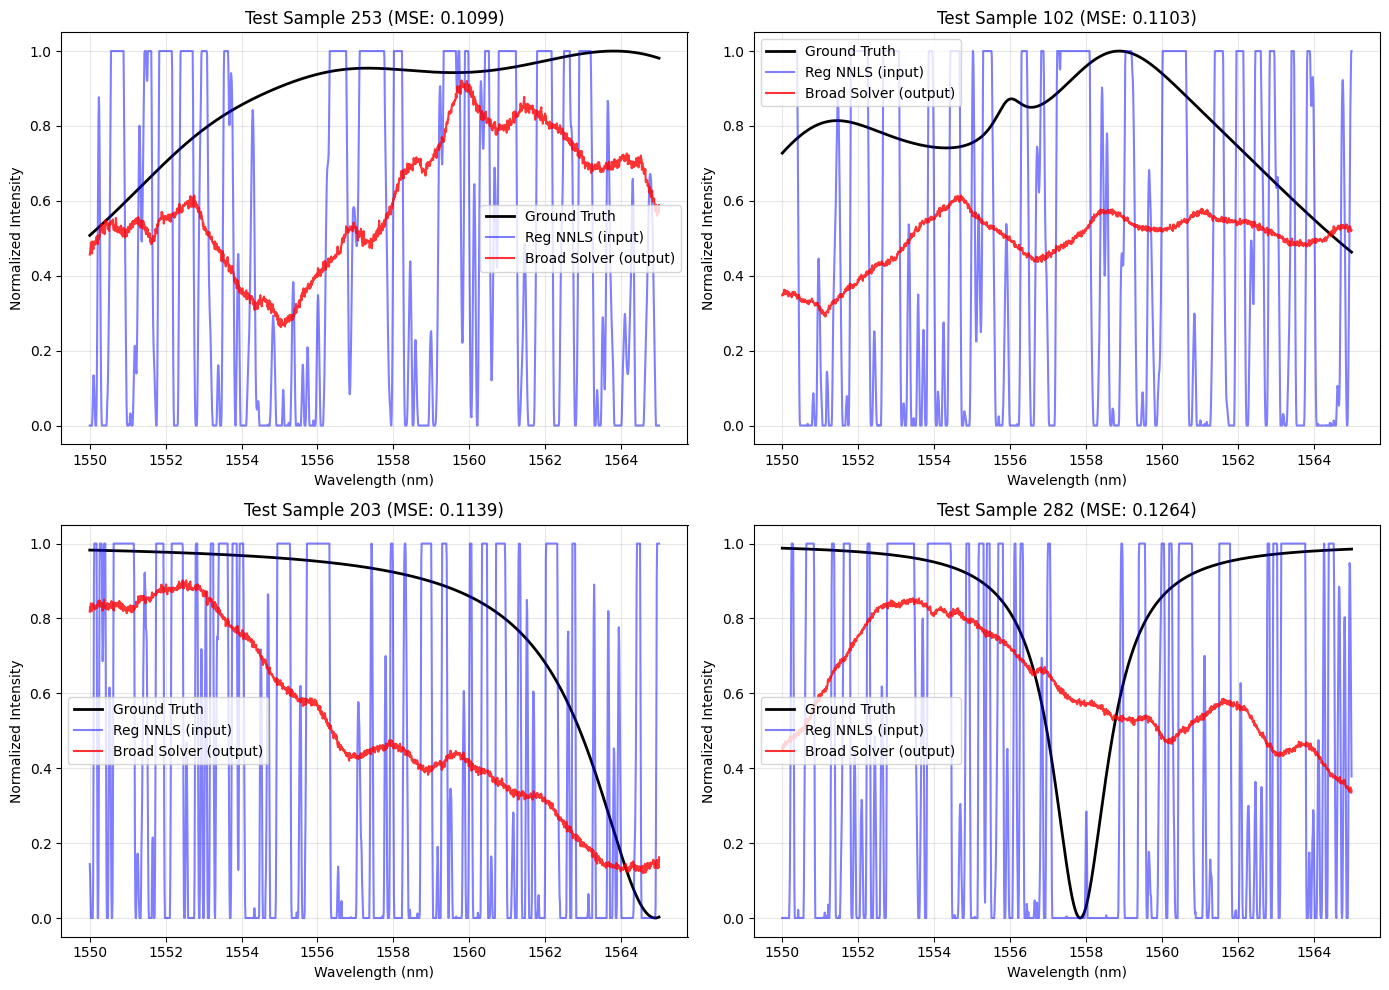

<Figure size 640x480 with 0 Axes>

In [76]:
sample_mse = np.mean((predictions - y_test) ** 2, axis=1)
worst_indices = np.argsort(sample_mse)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstWorstOutputs.png")

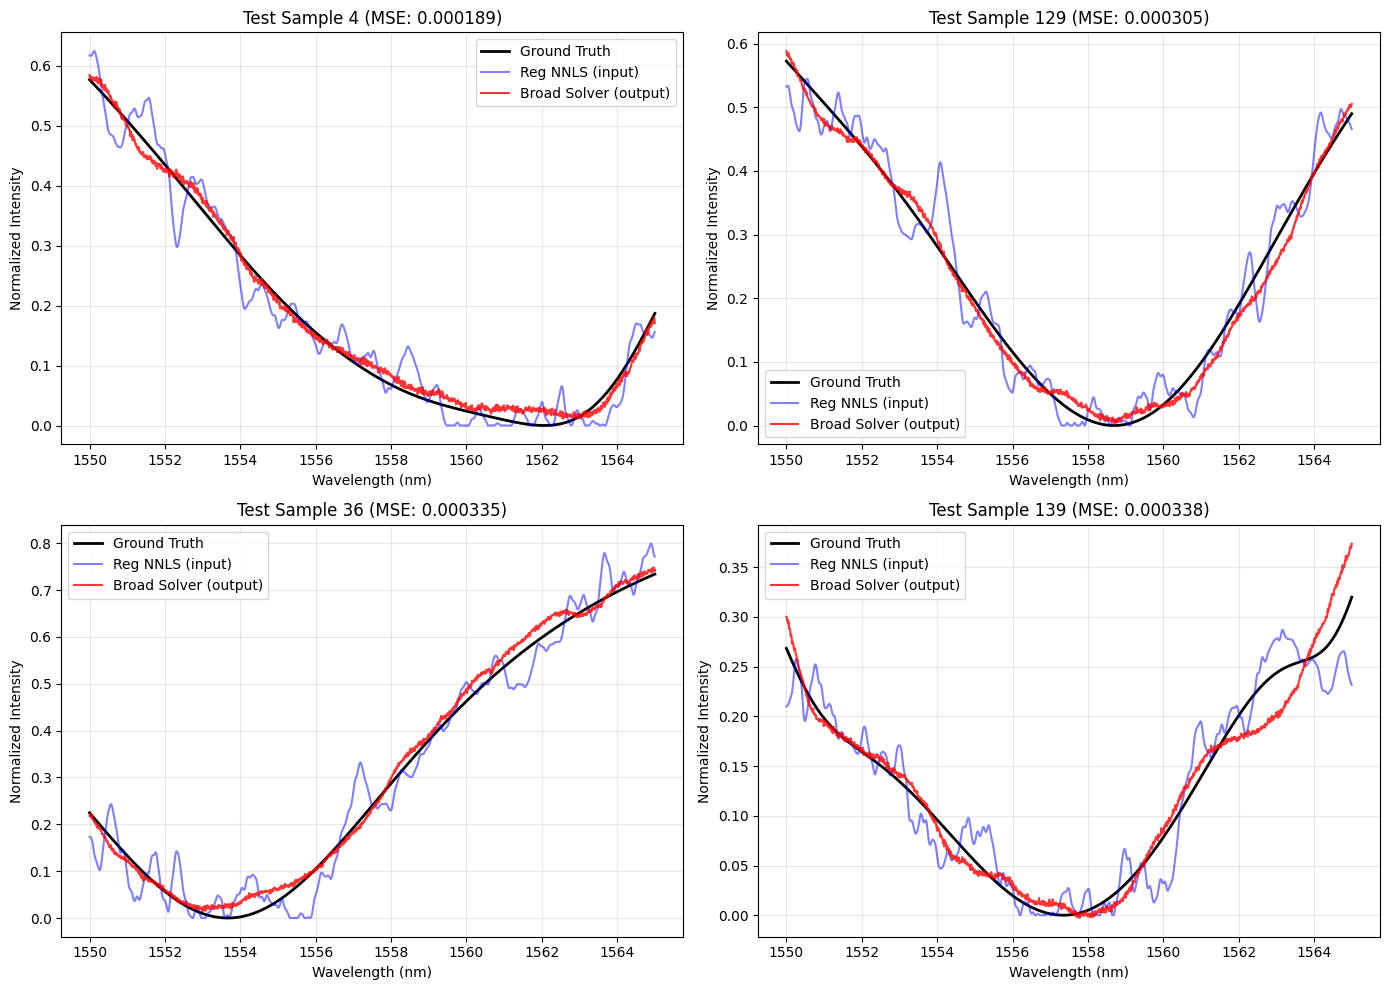

<Figure size 640x480 with 0 Axes>

In [77]:
sample_mse = np.mean((predictions - y_test) ** 2, axis=1)
best_indices = np.argsort(sample_mse)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(best_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse[idx]:.6f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstBestOutput.png")

In [ ]:
# Second Attempt
# Broad Network

class BroadSolverNetworkv3(nn.Module):
    def __init__(self):
        super().__init__()
    
        self.layer1 = nn.Linear(1500, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)

        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        residual = x
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return residual + x





In [ ]:
model_v2 = BroadSolverNetworkv2()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model_v2.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model_v2(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer_v2.zero_grad()
        loss.backward()

        # update the weights
        optimizer_v2.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.020733
Epoch 20/200, Loss: 0.013976
Epoch 30/200, Loss: 0.010751
Epoch 40/200, Loss: 0.009165
Epoch 50/200, Loss: 0.007914
Epoch 60/200, Loss: 0.007363
Epoch 70/200, Loss: 0.006987
Epoch 80/200, Loss: 0.006485
Epoch 90/200, Loss: 0.006271
Epoch 100/200, Loss: 0.006256
Epoch 110/200, Loss: 0.006207
Epoch 120/200, Loss: 0.005662
Epoch 130/200, Loss: 0.005870
Epoch 140/200, Loss: 0.005847
Epoch 150/200, Loss: 0.005629
Epoch 160/200, Loss: 0.005486
Epoch 170/200, Loss: 0.005508
Epoch 180/200, Loss: 0.005330
Epoch 190/200, Loss: 0.005453
Epoch 200/200, Loss: 0.005533


In [80]:
model_v2.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions_v2 = model_v2(X_test_tensor).numpy()

mse_before = np.mean((X_test - y_test) ** 2)
mse_after_v2 = np.mean((predictions_v2 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after (Broad Solver V2): {mse_after_v2:.6f}")
print(f"Improvement: {((mse_before - mse_after_v2) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after (Broad Solver V2): 0.021467
Improvement: 71.2%


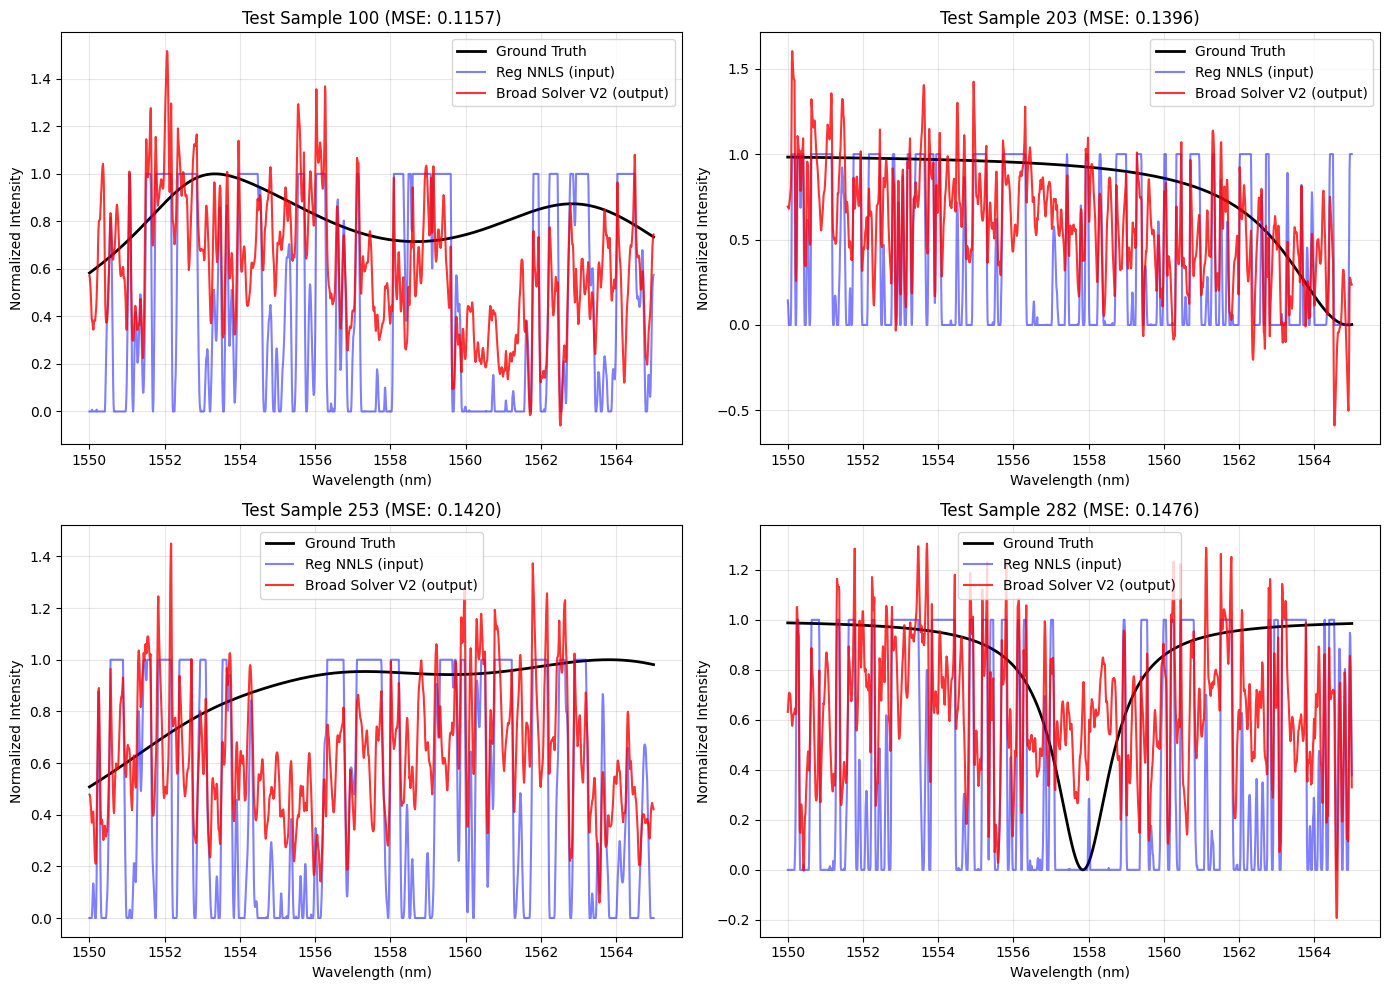

In [81]:
sample_mse_v2 = np.mean((predictions_v2 - y_test) ** 2, axis=1)
worst_indices_v2 = np.argsort(sample_mse_v2)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(worst_indices_v2):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v2[idx], label="Broad Solver V2 (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v2[idx]:.4f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

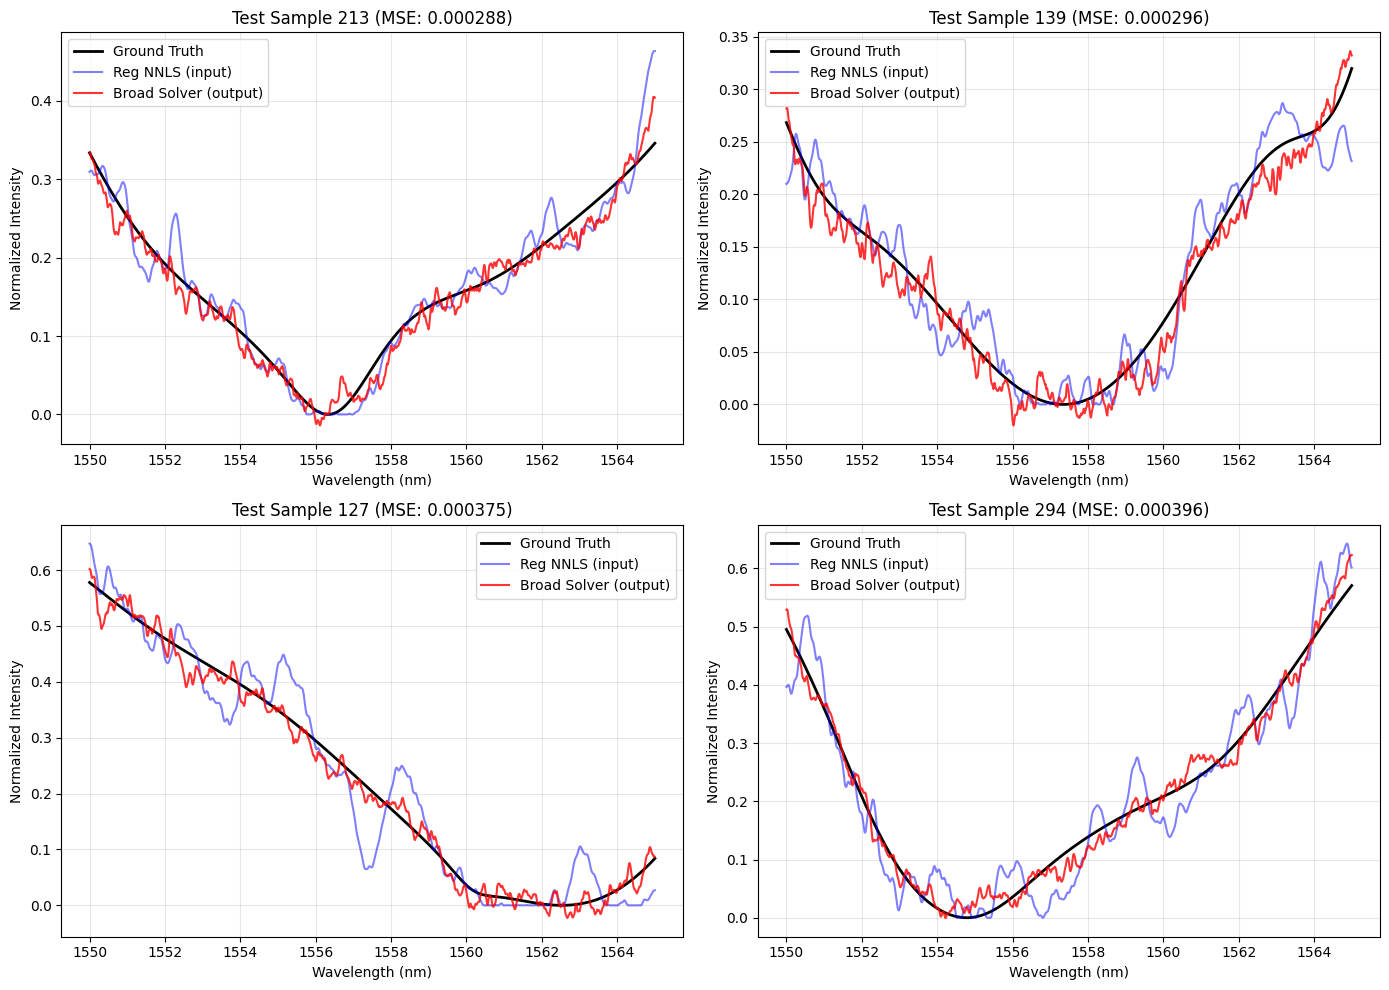

<Figure size 640x480 with 0 Axes>

In [82]:
sample_mse = np.mean((predictions_v2 - y_test) ** 2, axis=1)
best_indices = np.argsort(sample_mse_v2)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(best_indices):
    ax = axes[i]
    ax.plot(wavelengths, y_test[idx], label="Ground Truth", color="black", linewidth=2)
    ax.plot(wavelengths, X_test[idx], label="Reg NNLS (input)", color="blue", alpha=0.5)
    ax.plot(wavelengths, predictions_v2[idx], label="Broad Solver (output)", color="red", alpha=0.8)
    ax.set_title(f"Test Sample {idx} (MSE: {sample_mse_v2[idx]:.6f})")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalized Intensity")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("firstBestOutput.png")

In [83]:
class BroadSolverNetworkV3(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1 = nn.Linear(1500, 2048)
        self.layer2 = nn.Linear(2048, 1024)
        self.layer3 = nn.Linear(1024, 1500)
        
        self.ReLU = nn.ReLU()
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)
        
        x = self.layer2(x)
        x = self.ReLU(x)
        
        x = self.layer3(x)
        
        return x

In [84]:
model_v3 = BroadSolverNetworkV3()
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=1e-3)
num_epochs = 200

for epoch in range(num_epochs):
    model_v3.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        predicted = model_v3(batch_X)

        loss = broad_loss(predicted, batch_y)

        # backward pass
        optimizer_v3.zero_grad()
        loss.backward()

        # update the weights
        optimizer_v3.step()

        epoch_loss += loss.item()


    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 10/200, Loss: 0.006702
Epoch 20/200, Loss: 0.005397
Epoch 30/200, Loss: 0.003637
Epoch 40/200, Loss: 0.003149
Epoch 50/200, Loss: 0.003001
Epoch 60/200, Loss: 0.002037
Epoch 70/200, Loss: 0.002658
Epoch 80/200, Loss: 0.001839
Epoch 90/200, Loss: 0.001741
Epoch 100/200, Loss: 0.001517
Epoch 110/200, Loss: 0.001649
Epoch 120/200, Loss: 0.001228
Epoch 130/200, Loss: 0.001029
Epoch 140/200, Loss: 0.001833
Epoch 150/200, Loss: 0.000776
Epoch 160/200, Loss: 0.000798
Epoch 170/200, Loss: 0.001273
Epoch 180/200, Loss: 0.000739
Epoch 190/200, Loss: 0.000821
Epoch 200/200, Loss: 0.001426


In [ ]:
model_v3.eval()

X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    predictions_v3 = model_v3(X_test_tensor).numpy()

mse_after_v3 = np.mean((predictions_v3 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after V1 (original): 0.010952")
print(f"MSE after V3 (wider): {mse_after_v3:.6f}")
print(f"V3 Improvement over Reg NNLS: {((mse_before - mse_after_v3) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after V1 (original): 0.010952
MSE after V3 (wider): 0.010483
V3 Improvement over Reg NNLS: 85.9%


In [98]:
split = int(0.8 * len(X_broad_rough))

X_broad_raw = X_train_np[broad_mask]

X_raw_train = X_broad_raw[:split]
X_raw_test = X_broad_raw[split:]

print(f"Raw train shape: {X_raw_train.shape}")
print(f"Raw test shape: {X_raw_test.shape}")

Raw train shape: (1183, 25)
Raw test shape: (296, 25)


In [99]:
class BroadSpectrumDatasetV2(Dataset):
    def __init__(self, X_rough, X_raw, y):
        self.X_rough = torch.from_numpy(X_rough).float()
        self.X_raw = torch.from_numpy(X_raw).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X_rough)
    
    def __getitem__(self, idx):
        return self.X_rough[idx], self.X_raw[idx], self.y[idx]

mean = np.load('data/normalization_mean.npy')
std = np.load('data/normalization_std.npy')

X_raw_train_norm = (X_raw_train - mean) / std
X_raw_test_norm = (X_raw_test - mean) / std
# print(X_test.shape)
print(X_raw_test_norm.shape)


train_dataset_v2 = BroadSpectrumDatasetV2(X_train, X_raw_train_norm, y_train)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True)


(296, 25)


In [100]:
class BroadSolverNetworkV4(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1 = nn.Linear(1525, 1024)
        self.layer2 = nn.Linear(1024, 512)
        self.layer3 = nn.Linear(512, 1500)
        
        self.ReLU = nn.ReLU()
    
    def forward(self, x_rough, x_raw):
        x = torch.cat([x_rough, x_raw], dim=1)
        
        x = self.layer1(x)
        x = self.ReLU(x)
        
        x = self.layer2(x)
        x = self.ReLU(x)
        
        x = self.layer3(x)
        
        return x

In [101]:
model_v4 = BroadSolverNetworkV4()
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=1e-3)

for epoch in range(200):
    model_v4.train()
    epoch_loss = 0.0
    
    for batch_rough, batch_raw, batch_y in train_loader_v2:
        predicted = model_v4(batch_rough, batch_raw)
        loss = broad_loss(predicted, batch_y)
        
        optimizer_v4.zero_grad()
        loss.backward()
        optimizer_v4.step()
        
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader_v2)
        print(f"Epoch {epoch+1}/200, Loss: {avg_loss:.6f}")

Epoch 10/200, Loss: 0.007208
Epoch 20/200, Loss: 0.004737
Epoch 30/200, Loss: 0.004540
Epoch 40/200, Loss: 0.003128
Epoch 50/200, Loss: 0.002798
Epoch 60/200, Loss: 0.002724
Epoch 70/200, Loss: 0.002461
Epoch 80/200, Loss: 0.001999
Epoch 90/200, Loss: 0.002691
Epoch 100/200, Loss: 0.001956
Epoch 110/200, Loss: 0.001756
Epoch 120/200, Loss: 0.001752
Epoch 130/200, Loss: 0.001717
Epoch 140/200, Loss: 0.001133
Epoch 150/200, Loss: 0.001216
Epoch 160/200, Loss: 0.001278
Epoch 170/200, Loss: 0.001142
Epoch 180/200, Loss: 0.001507
Epoch 190/200, Loss: 0.000838
Epoch 200/200, Loss: 0.001239


In [102]:
print(X_test.shape)
print(X_raw_test_norm.shape)


(296, 1500)
(296, 25)


In [103]:
model_v4.eval()
X_test_tensor = torch.from_numpy(X_test).float()
X_raw_test_norm_tensor = torch.from_numpy(X_raw_test_norm).float()


with torch.no_grad():
    predictions_v4 = model_v4(X_test_tensor, X_raw_test_norm_tensor).numpy()

mse_after_v4 = np.mean((predictions_v4 - y_test) ** 2)

print(f"MSE before (Reg NNLS): {mse_before:.6f}")
print(f"MSE after V1 (original): 0.010952")
print(f"MSE after V4 (wider): {mse_after_v4:.6f}")
print(f"V3 Improvement over Reg NNLS: {((mse_before - mse_after_v4) / mse_before) * 100:.1f}%")

MSE before (Reg NNLS): 0.074441
MSE after V1 (original): 0.010952
MSE after V4 (wider): 0.011240
V3 Improvement over Reg NNLS: 84.9%
